In [1]:
import os,sys
os.chdir(r"E:\student\模型")

!"{sys.executable}" -m traffic_detector.training.train_flow_mlp \
    --epochs 8 \
    --batch-size 512 \
    --lr 1e-3 \
    --hidden-dims "256,256,128,64"


Epoch 1/8 | Train Loss=0.3458 | Train Acc=0.8382 | Val Loss=0.3053 | Val Acc=0.8565 | Val F1=0.8520 | Val MCC=0.7258
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 2/8 | Train Loss=0.3095 | Train Acc=0.8557 | Val Loss=0.3754 | Val Acc=0.8317 | Val F1=0.8352 | Val MCC=0.6653
Epoch 3/8 | Train Loss=0.2953 | Train Acc=0.8604 | Val Loss=0.3090 | Val Acc=0.8591 | Val F1=0.8575 | Val MCC=0.7260
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 4/8 | Train Loss=0.2908 | Train Acc=0.8626 | Val Loss=0.3639 | Val Acc=0.8315 | Val F1=0.8352 | Val MCC=0.6647
Epoch 5/8 | Train Loss=0.2875 | Train Acc=0.8642 | Val Loss=0.3146 | Val Acc=0.8590 | Val F1=0.8584 | Val MCC=0.7243
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 6/8 | Train Loss=0.2848 | Train Acc=0.8649 | Val Loss=0.3644 | Val Acc=0.8321 | Val F1=0.8365 | Val MCC=0.6654
Epoch 7/8 | Train L

In [1]:
import os, sys

# 切到项目根目录
os.chdir(r"E:\student\模型")

# 正式训练：比如最多 20 轮，有 early stopping 会提前停
!"{sys.executable}" -m traffic_detector.training.train_flow_mlp \
    --epochs 20 \
    --batch-size 512 \
    --lr 1e-3 \
    --hidden-dims "256,256,128,64"



Epoch 1/20 | Train Loss=0.3463 | Train Acc=0.8376 | Val Loss=0.3189 | Val Acc=0.8480 | Val F1=0.8474 | Val MCC=0.7023
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 2/20 | Train Loss=0.3116 | Train Acc=0.8551 | Val Loss=0.2922 | Val Acc=0.8604 | Val F1=0.8579 | Val MCC=0.7303
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 3/20 | Train Loss=0.2994 | Train Acc=0.8602 | Val Loss=0.2944 | Val Acc=0.8581 | Val F1=0.8586 | Val MCC=0.7210
Epoch 4/20 | Train Loss=0.2917 | Train Acc=0.8627 | Val Loss=0.3504 | Val Acc=0.8425 | Val F1=0.8468 | Val MCC=0.6861
Epoch 5/20 | Train Loss=0.2879 | Train Acc=0.8642 | Val Loss=0.3752 | Val Acc=0.8408 | Val F1=0.8456 | Val MCC=0.6823
Epoch 6/20 | Train Loss=0.2854 | Train Acc=0.8652 | Val Loss=0.3571 | Val Acc=0.8376 | Val F1=0.8410 | Val MCC=0.6771
Epoch 7/20 | Train Loss=0.2835 | Train Acc=0.8658 | Val Loss=0.3007 | Val Acc=0.8568 | Val F1=0.8575 | Val

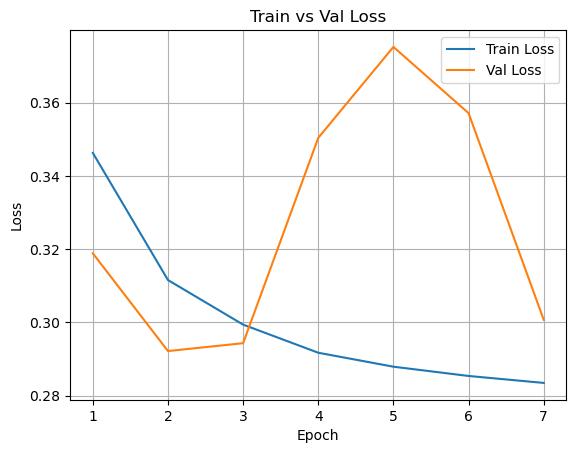

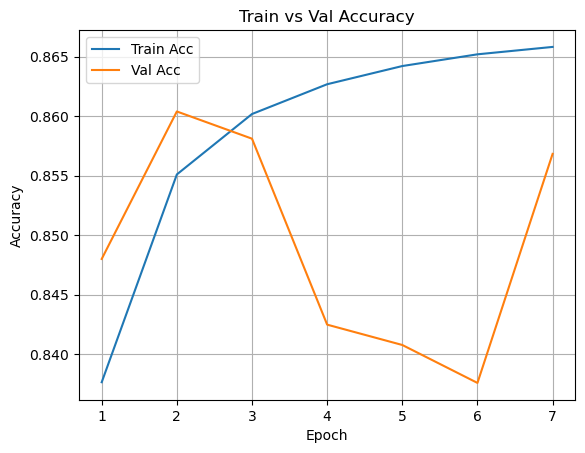

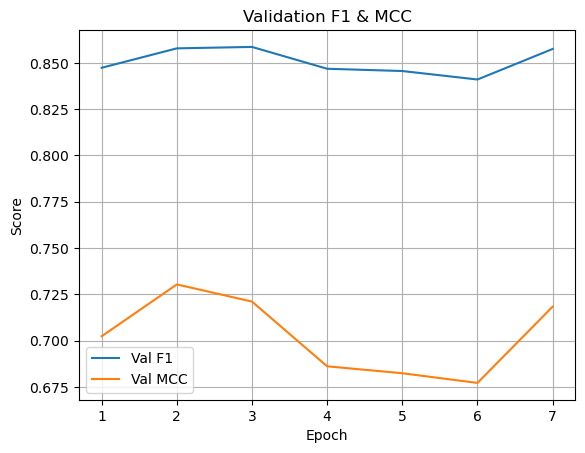

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# 让图显示在 notebook
%matplotlib inline

# 指标日志路径
project_root = Path(r"E:\student\模型")
history_path = project_root / "traffic_detector" / "checkpoints" / "flow_mlp_history.json"

with open(history_path, "r", encoding="utf-8") as f:
    history = json.load(f)

# 从 history 解析出各项曲线
epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
train_acc = [h["train_acc"] for h in history]
val_acc = [h["val_acc"] for h in history]
val_f1 = [h["val_f1"] for h in history]
val_mcc = [h["val_mcc"] for h in history]

# ===== 图 1：Loss 曲线 =====
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid(True)
plt.show()

# ===== 图 2：Accuracy 曲线（可选）=====
plt.figure()
plt.plot(epochs, train_acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ===== 图 3：F1 & MCC 曲线（验证集）=====
plt.figure()
plt.plot(epochs, val_f1, label="Val F1")
plt.plot(epochs, val_mcc, label="Val MCC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation F1 & MCC")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import os, sys
os.chdir(r"E:\student\模型")
if r"E:\student\模型" not in sys.path:
    sys.path.insert(0, r"E:\student\模型")

%env PYTHONUNBUFFERED=1
!"{sys.executable}" -u -m traffic_detector.training.train_flow_mlp --epochs 20 --batch-size 512 --lr 1e-3 --hidden-dims "256,256,128,64"

env: PYTHONUNBUFFERED=1
[setup] device=cuda, epochs=20, batch_size=512
[data] loading CSVs: attack=E:\student\模型\traffic_detector\data\raw\dataset_attack.csv, normal=E:\student\模型\traffic_detector\data\raw\dataset_normal.csv
[fit_transform] read csv done: attack_shape=(2990062, 29), normal_shape=(2668936, 29)
[fit_transform] merged shape=(5658998, 30), building flow features...
[fit_transform] flow features ready, columns=42
[fit_transform] mapped to matrix: X_raw shape=(5658998, 38)
[fit_transform] scaling done
[data] finished feature build: X shape=(5658998, 38), y shape=(5658998,)
[split] train=4527198 rows, val=1131800 rows, input_dim=38
[model] FlowMLPDetector initialized. hidden_dims=[256, 256, 128, 64], params=184705
[train] start training loop
Epoch 1/20 | Train Loss=0.3210 | Train Acc=0.8472 | Val Loss=0.2807 | Val Acc=0.8614 | Val F1=0.8541 | Val MCC=0.7419
[Checkpoint] Saved best model to E:\student\模型\traffic_detector\checkpoints\flow_mlp_best.pt
Epoch 2/20 | Train Loss=0.2

最佳 Epoch: 8, Val F1=0.8759, Val MCC=0.7628


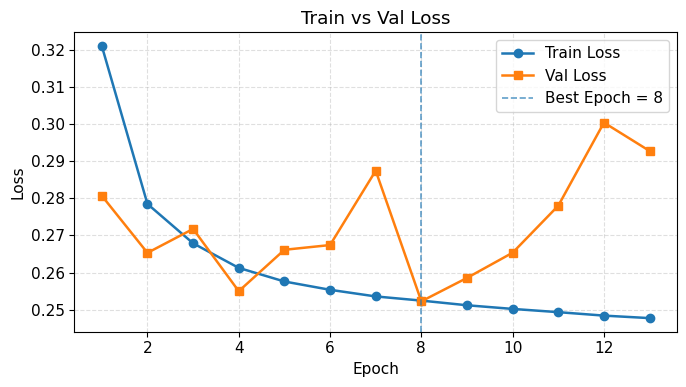

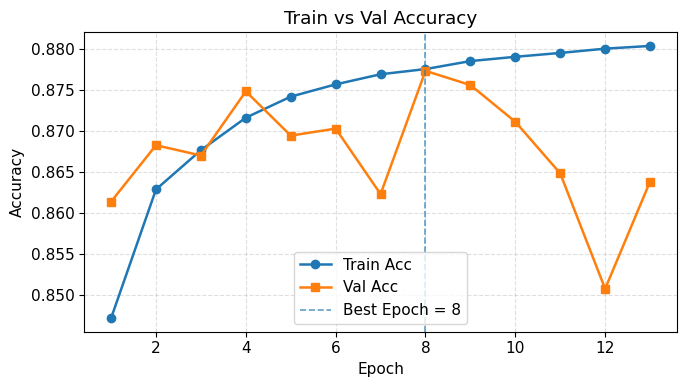

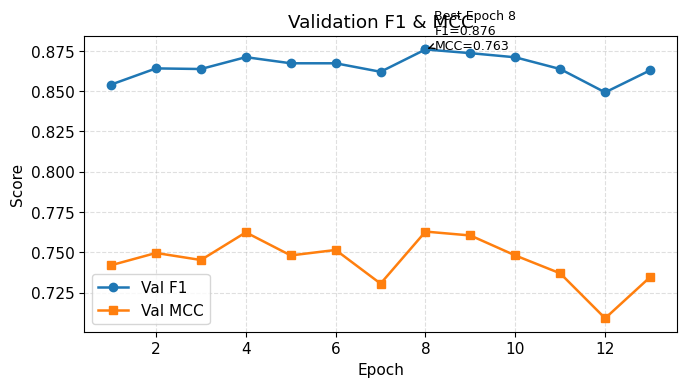

In [6]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# ==== 1. 读取训练历史 ====
history_path = Path(r"E:\student\模型") / "traffic_detector" / "checkpoints" / "flow_mlp_history.json"

with open(history_path, "r", encoding="utf-8") as f:
    history = json.load(f)

epochs   = np.array([h["epoch"]      for h in history])
train_loss = np.array([h["train_loss"] for h in history])
val_loss   = np.array([h["val_loss"]   for h in history])
train_acc  = np.array([h["train_acc"]  for h in history])
val_acc    = np.array([h["val_acc"]    for h in history])
val_f1     = np.array([h["val_f1"]     for h in history])
val_mcc    = np.array([h["val_mcc"]    for h in history])

# 找到 F1 或 MCC 最优的 epoch（你可以选一个）
best_idx = int(val_f1.argmax())
best_epoch = epochs[best_idx]
best_f1 = val_f1[best_idx]
best_mcc = val_mcc[best_idx]

print(f"最佳 Epoch: {best_epoch}, Val F1={best_f1:.4f}, Val MCC={best_mcc:.4f}")

# ==== 2. 统一设置图的尺寸和字号 ====
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11

# ==== 图 1：Train / Val Loss ====
fig, ax = plt.subplots()
ax.plot(epochs, train_loss, marker="o", linewidth=1.8, label="Train Loss")
ax.plot(epochs, val_loss,   marker="s", linewidth=1.8, label="Val Loss")

# 标出最佳 epoch（按 F1）
ax.axvline(best_epoch, linestyle="--", linewidth=1.2, alpha=0.7, label=f"Best Epoch = {best_epoch}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train vs Val Loss")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

# ==== 图 2：Train / Val Accuracy ====
fig, ax = plt.subplots()
ax.plot(epochs, train_acc, marker="o", linewidth=1.8, label="Train Acc")
ax.plot(epochs, val_acc,   marker="s", linewidth=1.8, label="Val Acc")
ax.axvline(best_epoch, linestyle="--", linewidth=1.2, alpha=0.7, label=f"Best Epoch = {best_epoch}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Val Accuracy")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

# ==== 图 3：Val F1 & MCC（重点展示模型性能）====
fig, ax = plt.subplots()
ax.plot(epochs, val_f1,  marker="o", linewidth=1.8, label="Val F1")
ax.plot(epochs, val_mcc, marker="s", linewidth=1.8, label="Val MCC")

# 标注最佳点（以 F1 为准）
ax.scatter([best_epoch], [best_f1], marker="o")
ax.annotate(
    f"Best Epoch {best_epoch}\nF1={best_f1:.3f}\nMCC={best_mcc:.3f}",
    xy=(best_epoch, best_f1),
    xytext=(best_epoch + 0.2, best_f1),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", linewidth=1.0)
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Validation F1 & MCC")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()
